# Capstone Project - Modelling Feature Set A

This notebook covers building and evaluating models for Feature Set A, which includes all the original variables without engineered features.

The main goals of this notebook are to:

1. Build and compare multiple classification models
2. Evaluate model performance using suitable metrics for an imbalanced classification problem
3. Compare models to see which perform best for my data

This notebook is kept separate from the EDA and feature engineering notebooks. The purpose here is to compare models for Feature Set A.


In [1]:
import sklearn
import imblearn
print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)


sklearn: 1.9.0
imblearn: 0.14.2


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.ensemble import (
    BalancedRandomForestClassifier,
    BalancedBaggingClassifier,
    EasyEnsembleClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
repo = fetch_ucirepo(id=891)

X_raw = repo.data.features
y_raw = repo.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

Dataset loaded successfully.
Original shape: (253680, 22)


In [4]:
# Rename columns into easier format
df = df.rename(columns={
    'HighBP': 'high_bp',
    'HighChol': 'high_chol',
    'CholCheck': 'chol_check',
    'BMI': 'bmi',
    'Smoker': 'smoker',
    'Stroke': 'stroke',
    'HeartDiseaseorAttack': 'heart_disease',
    'PhysActivity': 'phys_activity',
    'Fruits': 'fruits',
    'Veggies': 'veggies',
    'HvyAlcoholConsump': 'heavy_alcohol',
    'AnyHealthcare': 'any_healthcare',
    'NoDocbcCost': 'no_doc_cost',
    'GenHlth': 'general_health',
    'MentHlth': 'mental_health_days',
    'PhysHlth': 'physical_health_days',
    'DiffWalk': 'difficulty_walking',
    'Sex': 'sex',
    'Age': 'age',
    'Education': 'education',
    'Income': 'income',
    'Diabetes_binary': 'diabetes'
})

df.head()

,high_bp,high_chol,chol_check,bmi,smoker,stroke,heart_disease,phys_activity,fruits,veggies,...,no_doc_cost,general_health,mental_health_days,physical_health_days,difficulty_walking,sex,age,education,income,diabetes
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [5]:
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count, "(" + str(round(duplicate_percent, 2)) + "% of the dataset)")

Duplicate rows: 24206 (9.54% of the dataset)


In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (229474, 22)


## 2.0 Defining Features and Target


In [7]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (229474, 21)
Target shape: (229474,)


In [8]:
target_summary = y.value_counts().to_frame(name='count')
target_summary['percentage'] = (y.value_counts(normalize=True) * 100).round(2)

target_summary

,count,percentage
diabetes,,
0,194377,84.71
1,35097,15.29


## 3.0 Feature Selection A


In [9]:
# Feature Set A: original cleaned features only
feature_set_a = [
    'high_bp', 'high_chol', 'chol_check', 'bmi', 'smoker', 'stroke',
    'heart_disease', 'phys_activity', 'fruits', 'veggies',
    'heavy_alcohol', 'any_healthcare', 'no_doc_cost',
    'general_health', 'mental_health_days', 'physical_health_days',
    'difficulty_walking', 'sex', 'age', 'education', 'income'
]

## 4.0 Defining Target Variable and Feature Set


In [10]:
y = df['diabetes']
X_a = df[feature_set_a]

In [11]:
print("Feature Set A shape:", X_a.shape)

Feature Set A shape: (229474, 21)


## 5.0 Feature Set A

This notebook looks at Feature Set A, which contains all 21 original features.

Feature Set A gives me a baseline before testing whether engineered features (Set B) or a reduced feature set (Set C) improve model performance. I have split these into separate notebooks so each feature set stays clear and reproducible.

For each model, I will look at:

- training accuracy
- test accuracy
- classification report
- confusion matrix
- false positives
- false negatives

This helps me compare not only overall performance, but also how well each model identifies the diabetes class.

At the end of the notebook I will add my conclusions for this feature set.


## 5.1 First Model: Logistic Regression


The first model I am going to use is logistic regression.

I am starting with logistic regression because it is a standard baseline for binary classification. It is simple, interpretable, and gives me a useful benchmark before moving into more complex models.


In [12]:
# Results list - create ONCE at the start of modelling, not inside each model
all_results = []

# Same split settings for every model in this notebook
TEST_SIZE = 0.25
RANDOM_STATE = 42

### Reproducibility settings

- Data: UCI BRFSS 2015 (id=891), duplicates removed → 229,474 rows
- Split: 75/25 stratified, `random_state=42`
- Scaling: `StandardScaler` fit on train only
- Slow models: 20k train subsample (RBF SVM, Balanced Random Forest, Easy Ensemble)
- Ensembles: 30k train subsample (Voting, Stacking)
- Balanced Bagging: full training set
- Evaluation: full test set (57,369 rows)


In [13]:
X = X_a
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:")
y_train_balance = y_train.value_counts(normalize=True)
print(y_train_balance.round(4))
print("Test class balance:")
y_test_balance = y_test.value_counts(normalize=True)
print(y_test_balance.round(4))

Train shape: (172105, 21)  Test shape: (57369, 21)
Train class balance:
diabetes
0    0.8471
1    0.1529
Name: proportion, dtype: float64
Test class balance:
diabetes
0    0.8471
1    0.1529
Name: proportion, dtype: float64


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

model = log_model
model_name = "Logistic Regression"

In [16]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7173
Training Classification Report:
              precision    recall  f1-score   support

           0     0.9412    0.7107    0.8099    145782
           1     0.3200    0.7541    0.4494     26323

    accuracy                         0.7173    172105
   macro avg     0.6306    0.7324    0.6296    172105
weighted avg     0.8462    0.7173    0.7547    172105



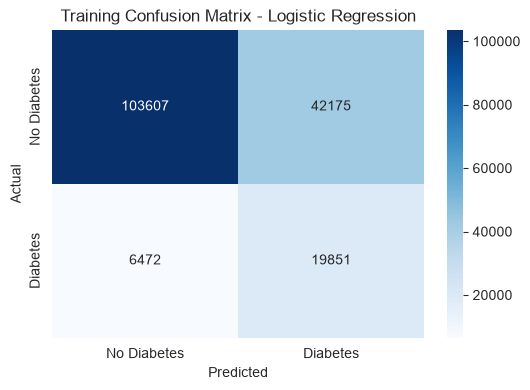

Training Confusion Matrix Breakdown
True Negatives:  103607
False Positives: 42175
False Negatives: 6472
True Positives:  19851


In [17]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [18]:
# Test predictions
y_test_pred = model.predict(X_test_scaled)
# Probability of the positive class (class 1)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]
# Test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7151
Precision:      0.3190
Recall:         0.7600
F1-score:       0.4493
ROC AUC:        0.8099

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9422    0.7070    0.8079     48595
           1     0.3190    0.7600    0.4493      8774

    accuracy                         0.7151     57369
   macro avg     0.6306    0.7335    0.6286     57369
weighted avg     0.8469    0.7151    0.7530     57369



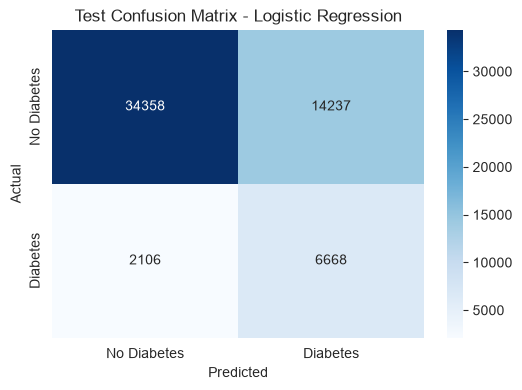

Test Confusion Matrix Breakdown
True Negatives:  34358
False Positives: 14237
False Negatives: 2106
True Positives:  6668


In [19]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [20]:
logistic_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(logistic_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.319,0.76,0.4493,0.8099,14237,2106


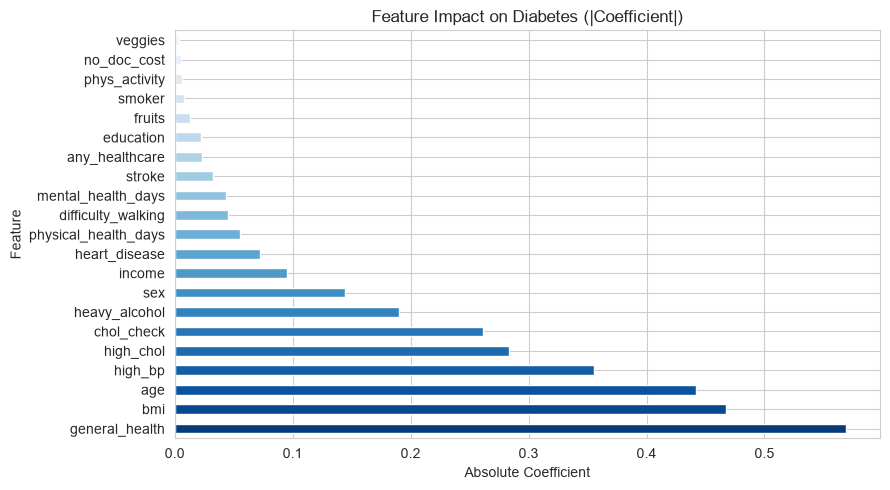

In [21]:
# Which features had the strongest effect (absolute coefficient size)
coef = pd.Series(
    np.abs(log_model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
coef.plot(kind='barh', color=sns.color_palette('Blues_r', len(coef)))
plt.title('Feature Impact on Diabetes (|Coefficient|)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Observation


For Feature Set A, the training and test accuracy were almost the same (0.7173 and 0.7151), showing the model generalises well and is not overfitting. What I am most focused on are the false negatives, where the model predicts someone does not have diabetes when they actually do. On the test set there were 2,106 false negatives, which is slightly higher than Feature Set B (2,094). Recall was strong at 0.76, meaning the model caught most positive cases, but precision was only 0.32, so quite a few people flagged as at risk were false alarms. This shows the model is good at identifying potential diabetes cases but could be improved to reduce false positives.

The feature impact chart shows that general_health, bmi, and age were the strongest predictors, with coefficients around 0.55, 0.47, and 0.43. That makes sense since poorer health, higher BMI, and older age are all known risk factors. Other features like high_bp, high_chol, and chol_check also mattered, while lifestyle factors such as phys_activity and fruits had smaller effects. Overall, Feature Set A performs well and highlights key health indicators, but using continuous BMI values might make it harder for the model to separate risk levels compared with the categorical approach in Feature Set B.


## 5.2 Second Model - Support Vector Machines - Linear Kernel

Linear SVM is my second model. Like logistic regression, it finds a linear decision boundary, but it uses a different approach (maximising the margin between classes).

I am using `LinearSVC` instead of `SVC(kernel='linear')` because it trains faster on large datasets like mine.

For ROC AUC, Linear SVM does not give probabilities, so I use `decision_function` scores instead.


In [22]:
# Train/test split and scaling already set up in Section 5.1
# Reusing X_train_scaled, X_test_scaled, y_train, y_test
print("Reusing existing split - Train:", X_train.shape, " Test:", X_test.shape)

Reusing existing split - Train: (172105, 21)  Test: (57369, 21)


In [23]:
# X_train_scaled and X_test_scaled already created in Section 5.1

In [24]:
from sklearn.svm import LinearSVC

In [25]:
linear_svm_model = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=20000
)

linear_svm_model.fit(X_train_scaled, y_train)

model = linear_svm_model
model_name = "Linear SVM"

In [26]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7136

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9420    0.7053    0.8066    145782
           1     0.3175    0.7594    0.4478     26323

    accuracy                         0.7136    172105
   macro avg     0.6298    0.7324    0.6272    172105
weighted avg     0.8465    0.7136    0.7518    172105



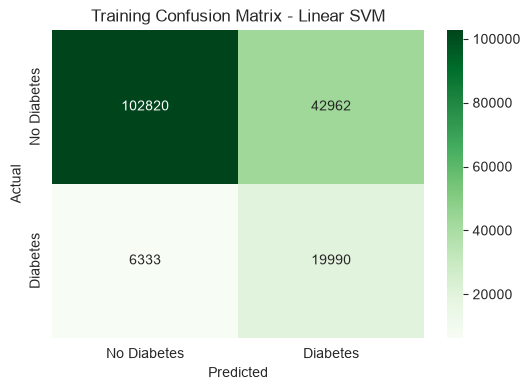

Training Confusion Matrix Breakdown
True Negatives:  102820
False Positives: 42962
False Negatives: 6333
True Positives:  19990


In [27]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [28]:
y_test_pred = model.predict(X_test_scaled)

y_test_scores = model.decision_function(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_scores)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7115
Precision:      0.3166
Recall:         0.7654
F1-score:       0.4480
ROC AUC:        0.8097

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9431    0.7017    0.8047     48595
           1     0.3166    0.7654    0.4480      8774

    accuracy                         0.7115     57369
   macro avg     0.6299    0.7336    0.6263     57369
weighted avg     0.8473    0.7115    0.7501     57369



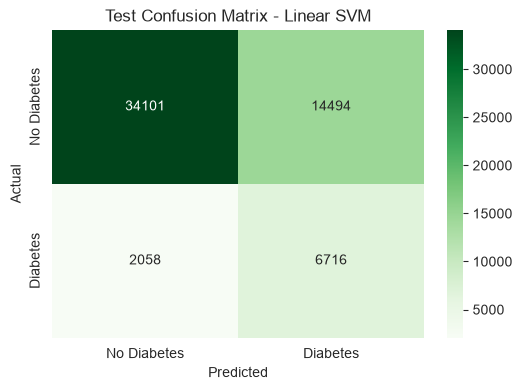

Test Confusion Matrix Breakdown
True Negatives:  34101
False Positives: 14494
False Negatives: 2058
True Positives:  6716


In [29]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [30]:
linear_svm_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(linear_svm_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058


### Observation


On Feature Set A, Linear SVM achieved a test recall of 0.7654 with 2,058 false negatives on the full test set (57,369 rows).

Compared with logistic regression (recall 0.76, 2,106 false negatives), Linear SVM caught slightly more diabetes cases, 48 fewer false negatives. That matters for this project because missing someone at risk is worse than a false alarm.

Both models had very similar overall performance:

- Test accuracy: logistic regression 0.7151 vs Linear SVM 0.7115
- ROC AUC: both around 0.81
- Precision: both around 0.32 (many false positives)

Linear SVM had slightly more false positives (14,494 vs 14,237), which is the trade-off from using `class_weight='balanced'` to push recall higher.

Overall, Linear SVM is slightly stronger on recall and false negatives, which is my main priority for diabetes screening. I will keep both models in the comparison and move on to RBF SVM next to see if a non-linear model can improve further.


## 5.3 Third Model - RBF SVM

RBF SVM can capture non-linear patterns that logistic regression and Linear SVM cannot.

Because RBF SVM is very slow on large datasets, I train on a stratified subsample of 20,000 rows.

Important:

- Do not use `probability=True` - it can hang on large data.
- Use `decision_function` for ROC AUC instead of `predict_proba`.
- I evaluate on the full test set (57,369 rows) so false negative counts are comparable with the linear models.


In [31]:
X_train_sub, X_train_sub_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=20000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train subsample shape:", X_train_sub.shape)
print("\nTrain subsample class balance:")
y_train_sub_balance = y_train_sub.value_counts(normalize=True)
print(y_train_sub_balance.round(4))

Train subsample shape: (20000, 21)

Train subsample class balance:
diabetes
0    0.847
1    0.153
Name: proportion, dtype: float64


In [32]:
rbf_svm_model = SVC(
    kernel='rbf',
    C=0.3,
    gamma='scale',
    class_weight='balanced',
    random_state=RANDOM_STATE
)

rbf_svm_model.fit(X_train_sub, y_train_sub)

model = rbf_svm_model
model_name = "RBF SVM"

In [33]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7268

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9569    0.7095    0.8148     16941
           1     0.3384    0.8231    0.4797      3059

    accuracy                         0.7268     20000
   macro avg     0.6477    0.7663    0.6472     20000
weighted avg     0.8623    0.7268    0.7636     20000



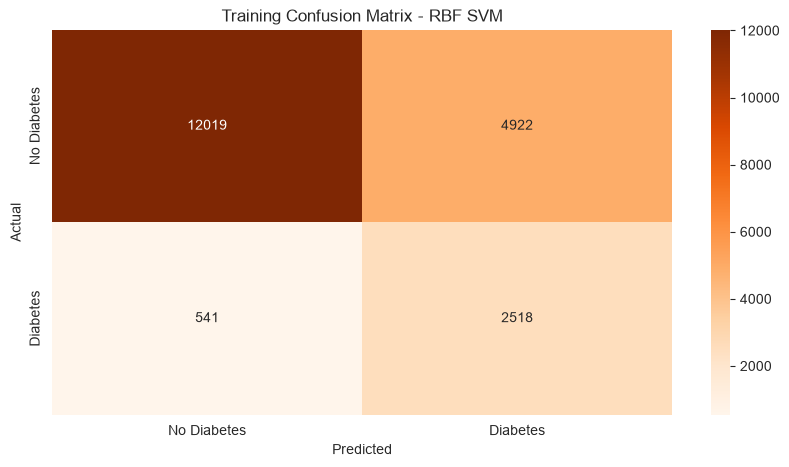

Training Confusion Matrix Breakdown
True Negatives: 12019
False Positives: 4922
False Negatives: 541
True Positives: 2518


In [34]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [35]:
y_test_pred = model.predict(X_test_scaled)
y_test_scores = model.decision_function(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_scores)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7048
Precision:      0.3124
Recall:         0.7746
F1-score:       0.4453
ROC AUC:        0.8034

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9445    0.6923    0.7989     48595
           1     0.3124    0.7746    0.4453      8774

    accuracy                         0.7048     57369
   macro avg     0.6285    0.7334    0.6221     57369
weighted avg     0.8478    0.7048    0.7448     57369



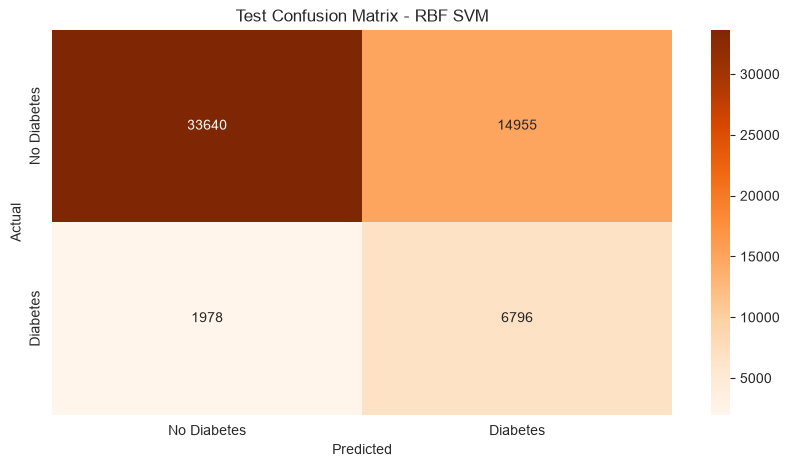

Test Confusion Matrix Breakdown
True Negatives: 33640
False Positives: 14955
False Negatives: 1978
True Positives: 6796


In [36]:
test_cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [37]:
rbf_svm_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(rbf_svm_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978


### Observation

RBF SVM was included to see if a non-linear model could capture more complex patterns than logistic regression and Linear SVM.

Because RBF SVM runs slowly on large datasets, I trained it on a stratified subsample of 20,000 rows and then evaluated it on the full test set (57,369 rows). I did not use `probability=True` and instead used `decision_function` for ROC AUC.

On Feature Set A, RBF SVM achieved a test recall of 0.7746 with 1,978 false negatives. Compared with logistic regression (recall 0.76, 2,106 FN) and Linear SVM (recall 0.7654, 2,058 FN), RBF SVM caught the most diabetes cases so far, with 80 fewer false negatives than Linear SVM and 128 fewer than logistic regression. That matters for screening because missing someone at risk is worse than a false alarm.

The trade-off was lower test accuracy (0.7048 vs about 0.71) and more false positives (14,955 vs 14,494 for Linear SVM). Precision stayed low at 0.31, and ROC AUC was 0.8034, slightly below the linear models (around 0.81).

Overall, RBF SVM performed best on recall and false negatives so far, but training and prediction took much longer. I will keep it in the comparison and move on to Gaussian Naive Bayes next.


## 5.4 Fourth Model - Gaussian Naive Bayes

Gaussian Naive Bayes is a fast probabilistic benchmark. It assumes features are independent, which is not fully true for health data (BMI, blood pressure, and similar factors are related), but it is still useful for comparison.

Because it is very fast, I train on the full train set (not a subsample).


In [38]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
model = nb_model
model_name = "Gaussian Naive Bayes"

In [39]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7557

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9106    0.7890    0.8455    145782
           1     0.3283    0.5712    0.4170     26323

    accuracy                         0.7557    172105
   macro avg     0.6195    0.6801    0.6312    172105
weighted avg     0.8216    0.7557    0.7799    172105



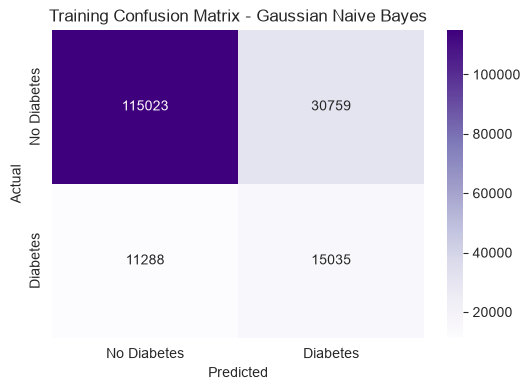

Training Confusion Matrix Breakdown
True Negatives:  115023
False Positives: 30759
False Negatives: 11288
True Positives:  15035


In [40]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [41]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7559
Precision:      0.3297
Recall:         0.5770
F1-score:       0.4196
ROC AUC:        0.7697

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9117    0.7882    0.8454     48595
           1     0.3297    0.5770    0.4196      8774

    accuracy                         0.7559     57369
   macro avg     0.6207    0.6826    0.6325     57369
weighted avg     0.8227    0.7559    0.7803     57369



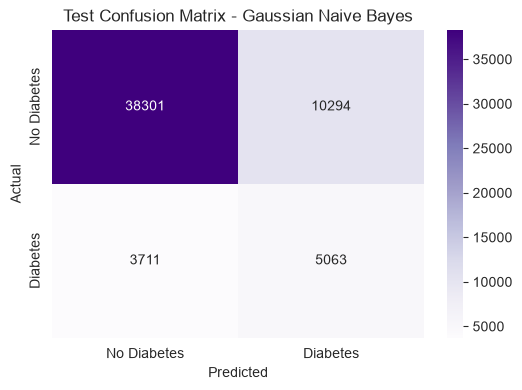

Test Confusion Matrix Breakdown
True Negatives:  38301
False Positives: 10294
False Negatives: 3711
True Positives:  5063


In [42]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [43]:
nb_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(nb_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711


### Observation

Gaussian Naive Bayes was trained on the full dataset because it is very fast, making it a good benchmark model. On Feature Set A, it achieved a test recall of 0.577 with 3,711 false negatives. Although it had the highest test accuracy (0.7559) among the models so far, it missed far more diabetes cases than logistic regression, Linear SVM, and RBF SVM.

In this project, recall matters more than accuracy because a false negative means someone at risk would not be identified. For that reason, Naive Bayes is not the preferred model even though it is quick and performs well on accuracy. One likely reason is that Naive Bayes assumes all input features are conditionally independent, which is not applicable for health-related variables like BMI, blood pressure, and general health, since these are often correlated.

Overall, Gaussian Naive Bayes is useful for comparison because of its speed, but it is not a strong choice for diabetes screening on Feature Set A.


## 6.0 Ensemble Methods


### Ensemble Models Overview

Ensemble methods combine multiple models to improve predictive performance.

This project uses five ensemble approaches:

1. Balanced Random Forest - builds decision trees on balanced bootstrap samples to improve minority-class detection.
2. Balanced Bagging - trains base learners on balanced subsets and averages their predictions to reduce variance and bias.
3. Easy Ensemble - creates several balanced subsets and applies boosting to each, enhancing recall for imbalanced datasets.
4. Voting Classifier - combines predictions from multiple models using soft voting to produce a more stable final probability.
5. Stacking Classifier - trains a meta-model on the outputs of base models to learn the best way to combine predictions.

### 6.1 Balanced Random Forest

Balanced Random Forest is a variant of the Random Forest algorithm designed for imbalanced datasets.

It builds multiple decision trees using balanced bootstrap samples. Each tree is trained on a subset where the minority and majority classes are equally represented.

This helps prevent bias toward the majority class (non-diabetes) and improves recall for the minority class (diabetes).


In [44]:
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

brf_model.fit(X_train_sub, y_train_sub)

model = brf_model
model_name = "Balanced Random Forest"

In [45]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.8949

Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8759    0.9339     16941
           1     0.5927    1.0000    0.7443      3059

    accuracy                         0.8949     20000
   macro avg     0.7964    0.9380    0.8391     20000
weighted avg     0.9377    0.8949    0.9049     20000



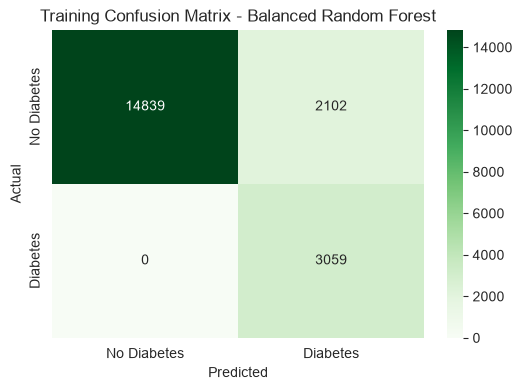

Training Confusion Matrix Breakdown
True Negatives:  14839
False Positives: 2102
False Negatives: 0
True Positives:  3059


In [46]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [47]:
y_test_pred = model.predict(X_test)
y_test_proba_all = model.predict_proba(X_test)
y_test_proba = y_test_proba_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))
print("Test ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.3001
Test Precision: 0.1755
Test Recall: 0.9669
Test F1 Score: 0.2971
Test ROC AUC: 0.6804

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9679    0.1797    0.3031     48595
           1     0.1755    0.9669    0.2971      8774

    accuracy                         0.3001     57369
   macro avg     0.5717    0.5733    0.3001     57369
weighted avg     0.8467    0.3001    0.3022     57369



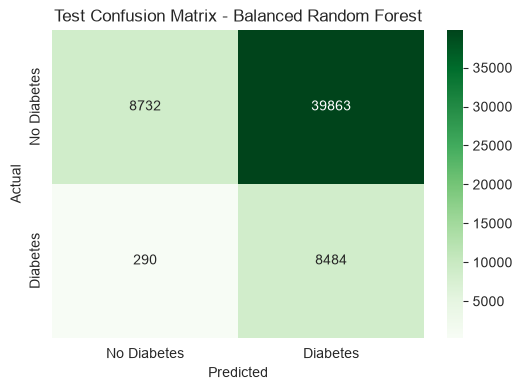

Test Confusion Matrix Breakdown
True Negatives:  8732
False Positives: 39863
False Negatives: 290
True Positives:  8484


In [48]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

Balanced Random Forest achieved very high recall on the training data, but its performance dropped sharply on the test set, suggesting overfitting and weak generalisation. Training accuracy was 0.89, while test accuracy fell to 0.30. On the test set, recall was 0.97, meaning the model caught almost all diabetes cases, but precision was only 0.18, and it produced 39,863 false positives.

This shows the model identified many people as diabetic, but most of those predictions were wrong. In this project, recall is important because missing a diabetes case is costly, but the number of false positives here is far too high to make the model practical. The huge gap between training and test accuracy also confirms the model does not generalise well.


In [49]:
brf_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(brf_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
4,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290


### 6.2 Balanced Bagging


Balanced Bagging combines the idea of bagging (bootstrap aggregation) with class balancing.

Each base estimator (often a decision tree) is trained on a balanced subset of the data, improving sensitivity to minority cases.

Predictions are averaged across all estimators to reduce variance and improve stability.


In [50]:
bbb_model = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    n_estimators=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bbb_model.fit(X_train, y_train)

model = bbb_model
model_name = "Balanced Bagging"

In [51]:
y_train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7258

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9541    0.7104    0.8144    145782
           1     0.3358    0.8108    0.4749     26323

    accuracy                         0.7258    172105
   macro avg     0.6450    0.7606    0.6447    172105
weighted avg     0.8595    0.7258    0.7625    172105



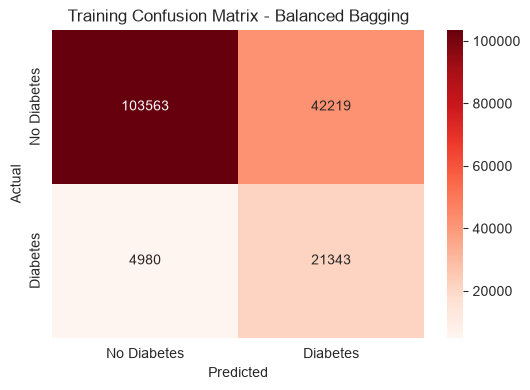

Training Confusion Matrix Breakdown
True Negatives:  103563
False Positives: 42219
False Negatives: 4980
True Positives:  21343


In [52]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [53]:
y_test_pred = model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7124
Test Precision: 0.3187
Test Recall: 0.7739
Test F1 Score: 0.4514

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9450    0.7013    0.8051     48595
           1     0.3187    0.7739    0.4514      8774

    accuracy                         0.7124     57369
   macro avg     0.6318    0.7376    0.6283     57369
weighted avg     0.8492    0.7124    0.7510     57369



In [54]:
y_test_proba_all = model.predict_proba(X_test)
y_test_proba = y_test_proba_all[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC", round(test_roc_auc, 4))

Test ROC-AUC: 0.8139


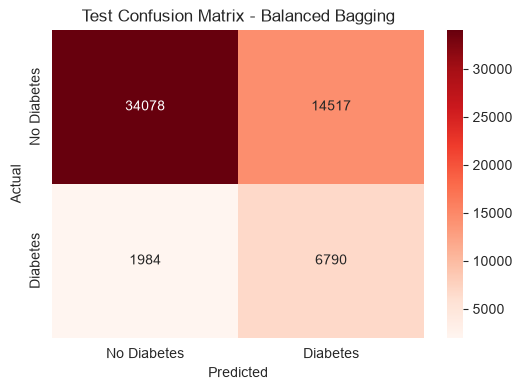

Test Confusion Matrix Breakdown
True Negatives:  34078
False Positives: 14517
False Negatives: 1984
True Positives:  6790


In [55]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

Balanced Bagging performed well on Feature Set A, with a test accuracy of 0.712 and a ROC AUC of 0.814. Its main strength was recall (0.774), meaning the model was able to detect most diabetes cases. This is important for this project since false negatives are more serious than false positives: missing someone at risk is worse than flagging someone incorrectly.

The model produced 1,984 false negatives, which is lower than several of the earlier models, but it also generated 14,517 false positives, resulting in a relatively low precision of 0.32. This shows the model was tuned to be more sensitive to positive cases, which helps catch more people at risk but also increases false alarms.

Overall, Balanced Bagging looks promising as a screening model because of its strong recall and balanced performance, though the high false positive rate would need to be managed if used in practice.


In [56]:
bbb_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(bbb_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
4,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
5,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984


### 6.3 Easy Ensemble


The Easy Ensemble method is specifically designed for highly imbalanced datasets.

It creates multiple balanced subsets of the majority class, trains an AdaBoost classifier on each, and then aggregates their predictions.

This approach combines boosting's ability to focus on hard-to-classify cases with balanced sampling to improve minority recall.


In [57]:
easy_model = EasyEnsembleClassifier(
    n_estimators=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

easy_model.fit(X_train_sub, y_train_sub)

model = easy_model
model_name = "Easy Ensemble"

In [58]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7251

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9440    0.7181    0.8157     16941
           1     0.3286    0.7640    0.4595      3059

    accuracy                         0.7251     20000
   macro avg     0.6363    0.7410    0.6376     20000
weighted avg     0.8498    0.7251    0.7612     20000



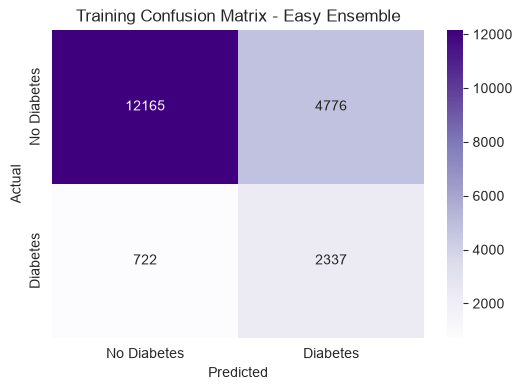

Training Confusion Matrix Breakdown
True Negatives:  12165
False Positives: 4776
False Negatives: 722
True Positives:  2337


In [59]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [60]:
y_test_pred = model.predict(X_test)
y_test_prob_all = model.predict_proba(X_test)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))
print("Test ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.1529
Test Precision: 0.1529
Test Recall: 1.0000
Test F1 Score: 0.2653
Test ROC AUC: 0.7312

Test Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     48595
           1     0.1529    1.0000    0.2653      8774

    accuracy                         0.1529     57369
   macro avg     0.0765    0.5000    0.1327     57369
weighted avg     0.0234    0.1529    0.0406     57369



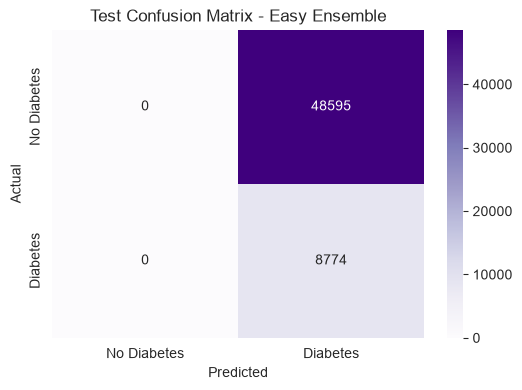

Test Confusion Matrix Breakdown
True Negatives:  0
False Positives: 48595
False Negatives: 0
True Positives:  8774


In [61]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Unpack confusion matrix values
cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

On Feature Set A, Easy Ensemble prioritised recall on the test set (see the metrics above). That means fewer diabetes cases were missed, which matters for this project because false negatives are the more serious screening error.

The trade-off is lower precision and many false positives when recall is pushed very high. Easy Ensemble is therefore most useful as a high-sensitivity benchmark. For routine screening, a model with a better recall and false-positive balance (such as RBF SVM or Balanced Bagging) is more practical unless a clear clinical follow-up pathway exists for flagged individuals.


In [62]:
easy_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(easy_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
4,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
5,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984
6,A,Easy Ensemble,0.7251,0.1529,0.1529,1.0000,0.2653,0.7312,48595,0


### 6.4 Voting Classifier

A Voting Classifier combines predictions from multiple base models (for example logistic regression, SVM, and Naive Bayes) to form a consensus.

In soft voting, it averages predicted probabilities rather than hard class labels, allowing models with higher confidence to influence the final decision more strongly.


In [63]:
X_train_sub, X_train_sub_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

voting_estimators = [
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
]

voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

voting_model.fit(X_train_sub, y_train_sub)

model = voting_model
model_name = "Voting Classifier"

In [64]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.8304

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9644    0.8304    0.8924     25412
           1     0.4691    0.8300    0.5994      4588

    accuracy                         0.8304     30000
   macro avg     0.7167    0.8302    0.7459     30000
weighted avg     0.8886    0.8304    0.8476     30000



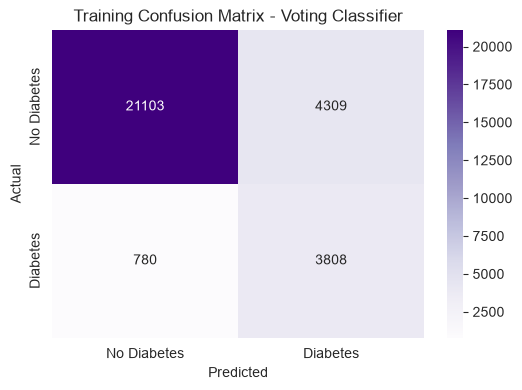

Training Confusion Matrix Breakdown
True Negatives:  21103
False Positives: 4309
False Negatives: 780
True Positives:  3808
True Positives:  8774


In [65]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)
print("True Positives", tp)

In [66]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7673
Precision: 0.3503
Recall: 0.6098
F1-score: 0.4450
ROC AUC: 0.8022

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9187    0.7958    0.8528     48595
           1     0.3503    0.6098    0.4450      8774

    accuracy                         0.7673     57369
   macro avg     0.6345    0.7028    0.6489     57369
weighted avg     0.8317    0.7673    0.7905     57369



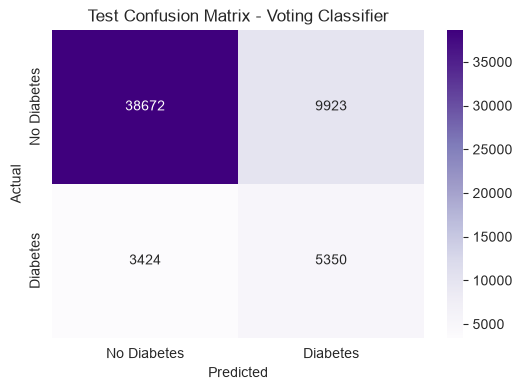

Test Confusion Matrix Breakdown
True Negatives:  38672
False Positives: 9923
False Negatives: 3424
True Positives:  5350


In [67]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

The Voting Classifier showed a balanced performance on Feature Set A, with a test accuracy of 0.767 and a ROC AUC of 0.802. Compared with the other ensemble models, it did not have the highest recall, but it managed a more practical balance between sensitivity and precision. Recall was 0.61, meaning some diabetes cases were still missed, shown by 3,424 false negatives.

On the positive side, the model reduced false positives to 9,923, which is much lower than the more aggressive ensemble methods. This helped improve precision to 0.35, making predictions more reliable overall.


In [68]:
voting_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(voting_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
4,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
5,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984
6,A,Easy Ensemble,0.7251,0.1529,0.1529,1.0000,0.2653,0.7312,48595,0
7,A,Voting Classifier,0.8304,0.7673,0.3503,0.6098,0.4450,0.8022,9923,3424


### 6.5 Stacking Classifier


Stacking is a two-level ensemble method.

Base models (level 1) make predictions, and a meta-model (level 2) learns how to best combine those predictions.

The meta-model can capture relationships between model outputs, often improving accuracy and generalisation.


In [69]:
X_train_sub_scaled, X_train_sub_scaled_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

stacking_estimators = [
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=3
)

stacking_model.fit(X_train_sub_scaled, y_train_sub)

model = stacking_model
model_name = "Stacking Classifier"

In [70]:
y_train_pred = model.predict(X_train_sub_scaled)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7880

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9853    0.7611    0.8588     25412
           1     0.4146    0.9372    0.5749      4588

    accuracy                         0.7880     30000
   macro avg     0.7000    0.8492    0.7169     30000
weighted avg     0.8980    0.7880    0.8154     30000



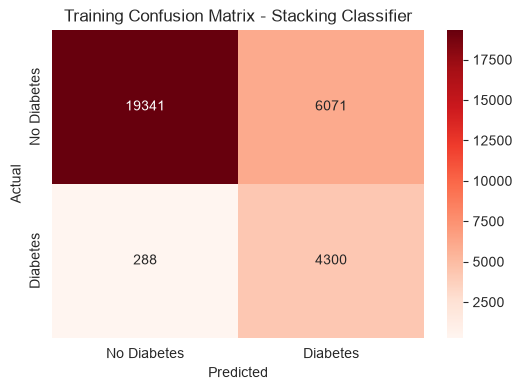

Training Confusion Matrix Breakdown
True Negatives:  19341
False Positives: 6071
False Negatives: 288
True Positives:  4300


In [71]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [72]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7231
Precision: 0.3242
Recall: 0.7473
F1-score: 0.4522
ROC AUC: 0.8116

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9403    0.7187    0.8147     48595
           1     0.3242    0.7473    0.4522      8774

    accuracy                         0.7231     57369
   macro avg     0.6323    0.7330    0.6335     57369
weighted avg     0.8461    0.7231    0.7593     57369



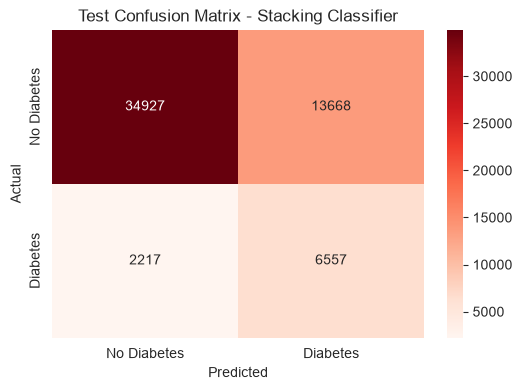

Test Confusion Matrix Breakdown
True Negatives:  34927
False Positives: 13668
False Negatives: 2217
True Positives:  6557


In [73]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

The Stacking Classifier performed well on Feature Set A, showing a good balance between recall and precision. It achieved a test accuracy of 0.723 and a ROC AUC of 0.812. Recall was 0.747, meaning the model detected most diabetes cases, which is important in this project since false negatives are more costly than false positives.

Compared with the Voting Classifier, the stacking model leaned more toward sensitivity, improving case detection but keeping precision lower at 0.32. It produced 2,217 false negatives and 13,668 false positives, which is a better balance than Easy Ensemble and Balanced Random Forest.

Overall, the Stacking Classifier offers a solid middle ground between recall and precision. It is more stable than the high-recall models and could be a good model for further tuning.


In [74]:
stacking_results_a = {
    'Feature Set': 'A',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(stacking_results_a)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
1,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
4,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
5,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984
6,A,Easy Ensemble,0.7251,0.1529,0.1529,1.0000,0.2653,0.7312,48595,0
7,A,Voting Classifier,0.8304,0.7673,0.3503,0.6098,0.4450,0.8022,9923,3424
8,A,Stacking Classifier,0.7880,0.7231,0.3242,0.7473,0.4522,0.8116,13668,2217


In [75]:
results_a = pd.DataFrame(all_results).round(4)

results_a = results_a.sort_values(
    by=['Recall', 'False Negatives'],
    ascending=[False, True]
).reset_index(drop=True)

results_a

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Easy Ensemble,0.7251,0.1529,0.1529,1.0000,0.2653,0.7312,48595,0
1,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984
4,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
5,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
6,A,Stacking Classifier,0.7880,0.7231,0.3242,0.7473,0.4522,0.8116,13668,2217
7,A,Voting Classifier,0.8304,0.7673,0.3503,0.6098,0.4450,0.8022,9923,3424
8,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711


In [76]:
results_a.to_csv('all_model_results_a.csv', index=False)
print('Saved: all_model_results_a.csv')

Saved: all_model_results_a.csv


## 7.0 Feature Set A - Summary and Conclusions

Feature Set A used the original dataset without any engineered features. The goal was to test how well standard models could predict diabetes using the raw health and lifestyle variables. For this project, recall and false negatives were the most important metrics, since missing someone at risk of diabetes is worse than incorrectly flagging them for screening.

### Model Comparison Table

| Feature Set | Model | Training Accuracy | Test Accuracy | Precision | Recall | F1-score |
|--------------|--------|------------------|---------------|------------|---------|-----------|
| A | Logistic Regression | 0.7173 | 0.7151 | 0.3190 | 0.7600 | 0.4493 |
| A | Linear SVM | 0.7136 | 0.7115 | 0.3166 | 0.7654 | 0.4480 |
| A | RBF SVM | 0.7268 | 0.7048 | 0.3124 | 0.7746 | 0.4453 |
| A | Gaussian Naive Bayes | 0.7557 | 0.7559 | 0.3297 | 0.5770 | 0.4196 |
| A | Balanced Random Forest | 0.8949 | 0.3001 | 0.1755 | 0.9669 | 0.2971 |
| A | Balanced Bagging | 0.7258 | 0.7124 | 0.3187 | 0.7739 | 0.4514 |
| A | Easy Ensemble | 0.7251 | 0.1529 | 0.1529 | 1.0000 | 0.2653 |
| A | Voting Classifier | 0.8304 | 0.7673 | 0.3503 | 0.6098 | 0.4450 |
| A | Stacking Classifier | 0.7880 | 0.7231 | 0.3242 | 0.7473 | 0.4522 |

### Summary

For minimising missed diabetes cases on Feature Set A, RBF SVM achieved the highest recall (0.7746) and fewest false negatives (1,978) among the practical models. Balanced Bagging was very close behind (recall 0.7739, 1,984 false negatives) and had the highest F1-score among the top recall models.

Linear SVM and logistic regression were also strong, showing that simpler models can perform very well without feature engineering.

Gaussian Naive Bayes was fast and accurate but weaker on recall, missing more positive cases. Balanced Random Forest and Easy Ensemble pushed recall very high but produced too many false positives, making them less practical for real screening.

Voting Classifier improved accuracy but missed more cases, while Stacking Classifier offered the best balance among the ensemble models.

### What I took away from Feature Set A

1. RBF SVM was the strongest practical model for minimising false negatives on Feature Set A. It achieved the highest recall (0.7746) and fewest false negatives (1,978).
2. Balanced Bagging was a very close alternative. Its recall (0.7739) and false negatives (1,984) were almost identical to RBF SVM.
3. Linear SVM and logistic regression were solid alternatives. Their results were close to the top models, showing that simpler models can still perform well.
4. Stacking Classifier was the best ensemble overall. It provided the most balanced performance across recall, precision, and ROC AUC.
5. Voting Classifier improved accuracy but missed more cases. It was less effective for recall-focused screening.
6. Gaussian Naive Bayes was useful as a quick benchmark but weaker on recall.
7. Balanced Random Forest and Easy Ensemble showed the risk of pushing recall too far. Easy Ensemble achieved perfect recall (1.0000) with zero false negatives but 48,595 false positives and very low test accuracy (0.1529). Balanced Random Forest showed a similar pattern (recall 0.9669, 290 false negatives, 39,863 false positives).
8. Accuracy alone is not enough for this data problem. Recall, false negatives, and the balance between sensitivity and reliability were more meaningful for evaluating diabetes screening models.

### Conclusion

For diabetes screening using Feature Set A, RBF SVM would be my first choice if the main goal is to minimise false negatives. It achieved the highest recall (0.7746) and missed the fewest diabetes cases (1,978) among the practical models tested.

Balanced Bagging is a very close alternative (recall 0.7739, 1,984 false negatives) and is also a strong option for identifying people at risk.

If the goal is to choose the best ensemble model overall, then Stacking Classifier would be the best choice. It did not achieve the top recall but provided the best overall balance across recall, F1-score, ROC AUC, and general model behaviour.

Feature Set A showed that the original variables already contained most of the predictive signal for diabetes risk.

Feature Sets B and C are tested in separat notebooks to see whether feature engineering or a reduced predictor set could improve on these results.